In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from sklearn.feature_selection import mutual_info_regression

In [ ]:
df = pd.read_csv('datos_1980-2025.csv')

In [ ]:
df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,WS/48,OBPM,DBPM,BPM,VORP,Awards,Share,Team_Abbr,W/L%,Season
0,4.0,Kareem Abdul-Jabbar,32.0,LAL,C,82.0,NaN,3143.0,25.3,0.639,...,0.227,4.8,2.4,7.2,7.3,"MVP-1,AS,NBA1,DEF1",0.665,LAL,0.732,1980
1,5.0,Moses Malone,24.0,HOU,C,82.0,82.0,3140.0,24.1,0.560,...,0.183,4.5,-2.4,2.1,3.2,"MVP-9,AS,NBA2",0.005,HOU,0.500,1980
2,10.0,Gus Williams,26.0,SEA,PG,82.0,82.0,2969.0,20.6,0.529,...,0.187,3.1,1.6,4.7,5.0,"MVP-8,NBA2",0.007,SEA,0.683,1980
3,11.0,Larry Bird,23.0,BOS,PF,82.0,82.0,2955.0,20.5,0.538,...,0.182,3.0,1.5,4.5,4.8,"MVP-4,ROY-1,AS,NBA1",0.068,BOS,0.744,1980
4,13.0,Dan Issel,31.0,DEN,C,82.0,82.0,2938.0,22.2,0.571,...,0.188,4.1,-0.8,3.3,3.9,NaN,0.000,DEN,0.366,1980


In [ ]:
df.describe()

,Rk,Age,G,GS,MP,PER,TS%,3PAr,FTr,ORB%,...,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Share,W/L%,Season
count,2082.000000,2082.000000,2082.000000,2039.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,...,2082.000000,2082.00000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2006.000000,2082.000000
mean,68.133045,26.888569,72.601825,62.742521,2388.308838,21.090778,0.577438,0.141488,0.374268,6.941402,...,2.965466,8.41316,0.168411,3.024207,0.416378,3.439721,3.392747,0.056320,0.557821,2005.058598
std,64.884247,3.846911,9.096073,23.224528,575.154718,2.815702,0.042364,0.152151,0.125535,4.048928,...,1.403919,3.14674,0.042647,1.928999,1.276105,2.387456,1.892297,0.173948,0.134361,13.171709
min,1.000000,19.000000,36.000000,0.000000,469.000000,18.000000,0.463000,0.000000,0.101000,0.800000,...,-0.300000,1.90000,0.062000,-1.600000,-3.000000,-1.900000,0.000000,0.000000,0.146000,1980.000000
25%,20.000000,24.000000,67.000000,57.000000,2040.000000,19.000000,0.548000,0.008000,0.287000,3.200000,...,1.900000,6.20000,0.140000,1.700000,-0.500000,1.800000,2.000000,0.000000,0.476000,1994.000000
50%,48.000000,26.000000,75.000000,72.000000,2479.500000,20.300000,0.573000,0.077000,0.357000,6.700000,...,2.800000,8.00000,0.165000,2.800000,0.300000,3.100000,3.100000,0.000000,0.573000,2006.000000
75%,95.000000,29.000000,80.000000,79.000000,2835.750000,22.400000,0.603000,0.253000,0.440750,9.800000,...,3.800000,10.20000,0.195000,4.100000,1.300000,4.700000,4.400000,0.003000,0.659000,2017.000000
max,337.000000,40.000000,85.000000,82.000000,3485.000000,32.800000,0.745000,0.680000,1.219000,21.500000,...,8.700000,21.20000,0.322000,10.300000,4.600000,13.700000,12.500000,1.000000,0.890000,2025.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2082 entries, 0 to 2081
Data columns (total 33 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Rk         2082 non-null   float64
 1   Player     2082 non-null   object 
 2   Age        2082 non-null   float64
 3   Team       2082 non-null   object 
 4   Pos        2082 non-null   object 
 5   G          2082 non-null   float64
 6   GS         2039 non-null   float64
 7   MP         2082 non-null   float64
 8   PER        2082 non-null   float64
 9   TS%        2082 non-null   float64
 10  3PAr       2082 non-null   float64
 11  FTr        2082 non-null   float64
 12  ORB%       2082 non-null   float64
 13  DRB%       2082 non-null   float64
 14  TRB%       2082 non-null   float64
 15  AST%       2082 non-null   float64
 16  STL%       2082 non-null   float64
 17  BLK%       2082 non-null   float64
 18  TOV%       2082 non-null   float64
 19  USG%       2082 non-null   float64
 20  OWS     

# Tratamiento nulos

In [ ]:
# Team_Abbr y W/L% es nulo para jugadores traspasados a mitad de temporada (2TM, 3TM)
df[df['W/L%'].isnull()]

,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,WS/48,OBPM,DBPM,BPM,VORP,Awards,Share,Team_Abbr,W/L%,Season
21,59.0,Alex English,26.0,2TM,SF,78.0,15.0,2401.0,18.0,0.536,...,0.105,1.6,-1.2,0.4,1.5,NaN,0.0,NaN,NaN,1980
25,85.0,Bob Lanier,31.0,2TM,C,63.0,NaN,2131.0,20.4,0.592,...,0.168,2.6,0.6,3.1,2.8,NaN,0.0,NaN,NaN,1980
97,78.0,Cliff Robinson,21.0,2TM,PF,68.0,59.0,2175.0,18.3,0.491,...,0.077,0.3,-0.2,0.1,1.1,NaN,0.0,NaN,NaN,1982
125,38.0,World B. Free,29.0,2TM,SG,73.0,69.0,2638.0,18.4,0.519,...,0.104,2.2,-1.2,1.1,2.0,NaN,0.0,NaN,NaN,1983
311,64.0,Larry Nance,28.0,2TM,PF,67.0,60.0,2383.0,20.3,0.586,...,0.161,2.4,1.1,3.5,3.3,NaN,0.0,NaN,NaN,1988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1973,15.0,Pascal Siakam,29.0,2TM,PF,80.0,80.0,2657.0,19.7,0.601,...,0.124,2.6,-0.7,1.9,2.7,NaN,0.0,NaN,NaN,2024
2010,141.0,Daniel Gafford,25.0,2TM,C,74.0,66.0,1815.0,21.7,0.731,...,0.205,0.7,1.9,2.6,2.1,NaN,0.0,NaN,NaN,2024
2054,52.0,De'Aaron Fox,27.0,2TM,PG,62.0,62.0,2241.0,18.3,0.560,...,0.093,1.3,-1.0,0.4,1.3,NaN,0.0,NaN,NaN,2025
2066,138.0,Jimmy Butler,35.0,2TM,SF,55.0,55.0,1746.0,22.4,0.626,...,0.238,4.0,1.0,4.9,3.0,NaN,0.0,NaN,NaN,2025


In [ ]:
df[df['W/L%'].isnull()]['Share'].value_counts()

,count
Share,
0.000,71
0.001,1
0.003,1
0.002,1
0.027,1
0.010,1


In [ ]:
df = df.dropna(subset=['Team_Abbr', 'W/L%'])

In [ ]:
df[df['W/L%'].isnull()]

,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,WS/48,OBPM,DBPM,BPM,VORP,Awards,Share,Team_Abbr,W/L%,Season


In [ ]:
# Awards es nulo para los jugadores que no han recibido ningún premio
df[df['Awards'].isnull()]

,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,WS/48,OBPM,DBPM,BPM,VORP,Awards,Share,Team_Abbr,W/L%,Season
4,13.0,Dan Issel,31.0,DEN,C,82.0,82.0,2938.0,22.2,0.571,...,0.188,4.1,-0.8,3.3,3.9,NaN,0.0,DEN,0.366,1980
8,24.0,Mike Mitchell,24.0,CLE,SF,82.0,82.0,2802.0,19.1,0.557,...,0.142,2.1,-0.9,1.2,2.2,NaN,0.0,CLE,0.451,1980
10,32.0,Cedric Maxwell,24.0,BOS,SF,80.0,80.0,2744.0,19.0,0.679,...,0.214,2.8,0.7,3.5,3.8,NaN,0.0,BOS,0.744,1980
15,44.0,Mickey Johnson,27.0,IND,PF,82.0,61.0,2647.0,20.3,0.528,...,0.132,2.1,0.7,2.8,3.2,NaN,0.0,IND,0.451,1980
19,51.0,Ray Williams,25.0,NYK,PG,82.0,82.0,2582.0,21.6,0.546,...,0.152,3.7,0.3,3.9,3.9,NaN,0.0,NYK,0.476,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2077,231.0,Daniel Gafford,26.0,DAL,C,57.0,31.0,1226.0,24.7,0.716,...,0.232,2.7,1.1,3.8,1.8,NaN,0.0,DAL,0.476,2025
2078,275.0,Trayce Jackson-Davis,24.0,GSW,C,62.0,37.0,967.0,18.5,0.587,...,0.167,0.3,0.9,1.2,0.8,NaN,0.0,GSW,0.585,2025
2079,277.0,Jalen Smith,24.0,CHI,C,64.0,2.0,962.0,18.7,0.586,...,0.146,1.5,-0.6,0.9,0.7,NaN,0.0,CHI,0.476,2025
2080,321.0,Jay Huff,26.0,MEM,C,64.0,2.0,748.0,18.2,0.666,...,0.162,2.5,1.0,3.5,1.1,NaN,0.0,MEM,0.585,2025


In [ ]:
df['Awards'] = df['Awards'].fillna(value='No awards')

In [ ]:
df[df['Awards'].isnull()]

,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,WS/48,OBPM,DBPM,BPM,VORP,Awards,Share,Team_Abbr,W/L%,Season


In [ ]:
# Eliminamos columna GS ya que este dato no se recogía en las temporadas 1980-1981
df[df['GS'].isnull()]

,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,WS/48,OBPM,DBPM,BPM,VORP,Awards,Share,Team_Abbr,W/L%,Season
0,4.0,Kareem Abdul-Jabbar,32.0,LAL,C,82.0,NaN,3143.0,25.3,0.639,...,0.227,4.8,2.4,7.2,7.3,"MVP-1,AS,NBA1,DEF1",0.665,LAL,0.732,1980
5,15.0,George Gervin,27.0,SAS,SG,78.0,NaN,2934.0,24.0,0.587,...,0.173,5.5,-1.6,3.9,4.4,"MVP-3,AS,NBA1",0.086,SAS,0.500,1980
6,17.0,Otis Birdsong,24.0,KCK,SG,82.0,NaN,2885.0,18.5,0.538,...,0.143,2.0,0.1,2.1,3.0,AS,0.000,KCK,0.573,1980
9,26.0,Magic Johnson,20.0,LAL,SG,77.0,NaN,2795.0,20.6,0.602,...,0.180,3.1,1.7,4.8,4.8,"ROY-2,AS",0.000,LAL,0.732,1980
11,34.0,Marques Johnson,23.0,MIL,SF,77.0,NaN,2686.0,22.0,0.585,...,0.206,4.6,0.4,5.1,4.8,"AS,NBA2",0.000,MIL,0.598,1980
12,37.0,Adrian Dantley,24.0,UTA,SF,68.0,NaN,2674.0,24.3,0.635,...,0.189,5.3,-1.6,3.7,3.8,AS,0.000,UTA,0.293,1980
14,43.0,Kermit Washington,28.0,POR,PF,80.0,NaN,2657.0,18.2,0.584,...,0.165,1.3,0.6,1.9,2.6,"AS,DEF2",0.000,POR,0.463,1980
16,47.0,Eddie Johnson,24.0,ATL,SG,79.0,NaN,2622.0,18.0,0.538,...,0.150,2.5,0.3,2.8,3.2,"AS,DEF2",0.000,ATL,0.610,1980
17,49.0,Dan Roundfield,26.0,ATL,PF,81.0,NaN,2588.0,19.7,0.551,...,0.169,1.6,1.4,2.9,3.2,"MVP-5,AS,NBA2,DEF1",0.009,ATL,0.610,1980
18,50.0,World B. Free,26.0,SDC,SG,68.0,NaN,2585.0,22.7,0.544,...,0.148,4.9,-1.9,3.1,3.3,AS,0.000,SDC,0.427,1980


In [ ]:
df = df.drop(columns='GS')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2006 entries, 0 to 2081
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Rk         2006 non-null   float64
 1   Player     2006 non-null   object 
 2   Age        2006 non-null   float64
 3   Team       2006 non-null   object 
 4   Pos        2006 non-null   object 
 5   G          2006 non-null   float64
 6   MP         2006 non-null   float64
 7   PER        2006 non-null   float64
 8   TS%        2006 non-null   float64
 9   3PAr       2006 non-null   float64
 10  FTr        2006 non-null   float64
 11  ORB%       2006 non-null   float64
 12  DRB%       2006 non-null   float64
 13  TRB%       2006 non-null   float64
 14  AST%       2006 non-null   float64
 15  STL%       2006 non-null   float64
 16  BLK%       2006 non-null   float64
 17  TOV%       2006 non-null   float64
 18  USG%       2006 non-null   float64
 19  OWS        2006 non-null   float64
 20  DWS        20

# Tratamiento y eliminación columnas

In [ ]:
# Eliminamos Rk y Team_Abbr (está repetida)
df = df.drop(columns=['Rk', 'Team_Abbr'])

In [ ]:
# Mapeamos las posiciones a números 1-5
pos_mapping = {
    'PG': 1,
    'SG': 2,
    'SF': 3,
    'PF': 4,
    'C': 5
}

df['Pos'] = df['Pos'].map(pos_mapping)

display(df[['Player', 'Pos']].head())

,Player,Pos
0,Kareem Abdul-Jabbar,5
1,Moses Malone,5
2,Gus Williams,1
3,Larry Bird,4
4,Dan Issel,5


In [ ]:
# Método para extraer ranking MVP
def extract_mvp_rank(awards):
    if pd.isna(awards) or awards == 'None':
        return 0
    match = re.search(r'MVP-(\d+)', awards)
    if match:
        return int(match.group(1))
    return 0

df['MVP_Rank'] = df['Awards'].apply(extract_mvp_rank)

In [ ]:
df.head()

,Player,Age,Team,Pos,G,MP,PER,TS%,3PAr,FTr,...,WS/48,OBPM,DBPM,BPM,VORP,Awards,Share,W/L%,Season,MVP_Rank
0,Kareem Abdul-Jabbar,32.0,LAL,5,82.0,3143.0,25.3,0.639,0.001,0.344,...,0.227,4.8,2.4,7.2,7.3,"MVP-1,AS,NBA1,DEF1",0.665,0.732,1980,1
1,Moses Malone,24.0,HOU,5,82.0,3140.0,24.1,0.560,0.004,0.505,...,0.183,4.5,-2.4,2.1,3.2,"MVP-9,AS,NBA2",0.005,0.500,1980,9
2,Gus Williams,26.0,SEA,1,82.0,2969.0,20.6,0.529,0.023,0.274,...,0.187,3.1,1.6,4.7,5.0,"MVP-8,NBA2",0.007,0.683,1980,8
3,Larry Bird,23.0,BOS,4,82.0,2955.0,20.5,0.538,0.098,0.246,...,0.182,3.0,1.5,4.5,4.8,"MVP-4,ROY-1,AS,NBA1",0.068,0.744,1980,4
4,Dan Issel,31.0,DEN,5,82.0,2938.0,22.2,0.571,0.008,0.471,...,0.188,4.1,-0.8,3.3,3.9,No awards,0.000,0.366,1980,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2006 entries, 0 to 2081
Data columns (total 31 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Player    2006 non-null   object 
 1   Age       2006 non-null   float64
 2   Team      2006 non-null   object 
 3   Pos       2006 non-null   int64  
 4   G         2006 non-null   float64
 5   MP        2006 non-null   float64
 6   PER       2006 non-null   float64
 7   TS%       2006 non-null   float64
 8   3PAr      2006 non-null   float64
 9   FTr       2006 non-null   float64
 10  ORB%      2006 non-null   float64
 11  DRB%      2006 non-null   float64
 12  TRB%      2006 non-null   float64
 13  AST%      2006 non-null   float64
 14  STL%      2006 non-null   float64
 15  BLK%      2006 non-null   float64
 16  TOV%      2006 non-null   float64
 17  USG%      2006 non-null   float64
 18  OWS       2006 non-null   float64
 19  DWS       2006 non-null   float64
 20  WS        2006 non-null   float64
 

In [ ]:
# Calculamos la correlación de todo el dataset original, pero solo nos quedamos con la columna de 'Share'
correlation_with_share = df.select_dtypes(include=[np.number]).drop(columns=['Season', 'MVP_Rank'], errors='ignore').corr()['Share'].sort_values(ascending=False)

print(correlation_with_share)

Share    1.000000
PER      0.641955
VORP     0.621523
BPM      0.602444
WS       0.578890
WS/48    0.537677
OBPM     0.534502
OWS      0.509515
DWS      0.381183
USG%     0.362379
W/L%     0.327652
DBPM     0.319242
MP       0.241174
AST%     0.221380
STL%     0.129648
FTr      0.128220
G        0.115054
TS%      0.110713
DRB%     0.105341
TRB%     0.064399
Age      0.046428
BLK%     0.023482
3PAr     0.021029
TOV%     0.004548
Pos     -0.031184
ORB%    -0.044161
Name: Share, dtype: float64


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def compute_vif(dataframe):
    """
    Calcula el Factor de Inflación de la Varianza (VIF) para las variables de un DataFrame.
    Excluye automáticamente la constante del reporte final para limpiar la salida.
    """
    df2 = dataframe.copy() # Corrected: Use the passed 'dataframe' argument instead of global 'df'
    # 2. Añadir la columna de constante requerida por statsmodels para el intercepto
    X = add_constant(df2)

    # 3. Calcular el VIF para cada variable
    vif_data = pd.DataFrame()
    vif_data["Variable"] = df2.columns

    # Iteramos empezando en 1 para ignorar la columna 'const' en el resultado final
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]

    # 4. Ordenar de mayor a menor impacto de multicolinealidad
    return vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

# --- EJECUCIÓN ---
# Reemplaza 'X_eda' por el nombre de tu DataFrame de variables predictoras numéricas
# NOTA: Asegúrate de que NO incluya la variable objetivo 'Share'
X_eda = df.select_dtypes(include=[np.number]).drop(columns=['Season', 'Share', 'MVP_Rank'], errors='ignore')
vif_results = compute_vif(X_eda)

print("--- RESULTADOS DEL ANÁLISIS VIF ---")
print(vif_results)

--- RESULTADOS DEL ANÁLISIS VIF ---
   Variable          VIF
0        WS  4314.177072
1       OWS  2761.002393
2       BPM  2239.016792
3      TRB%  1655.923789
4      OBPM  1469.527042
5       DWS   857.943994
6      DRB%   781.649805
7      DBPM   642.008087
8      ORB%   245.130782
9      VORP    63.872263
10    WS/48    49.109413
11      PER    42.135013
12       MP    20.984191
13     USG%    12.859175
14     AST%     8.872702
15     BLK%     7.505153
16      Pos     7.180909
17     STL%     5.316066
18     3PAr     3.988984
19      TS%     3.911738
20     TOV%     3.349182
21     W/L%     3.038168
22        G     2.665941
23      FTr     2.041601
24      Age     1.197893


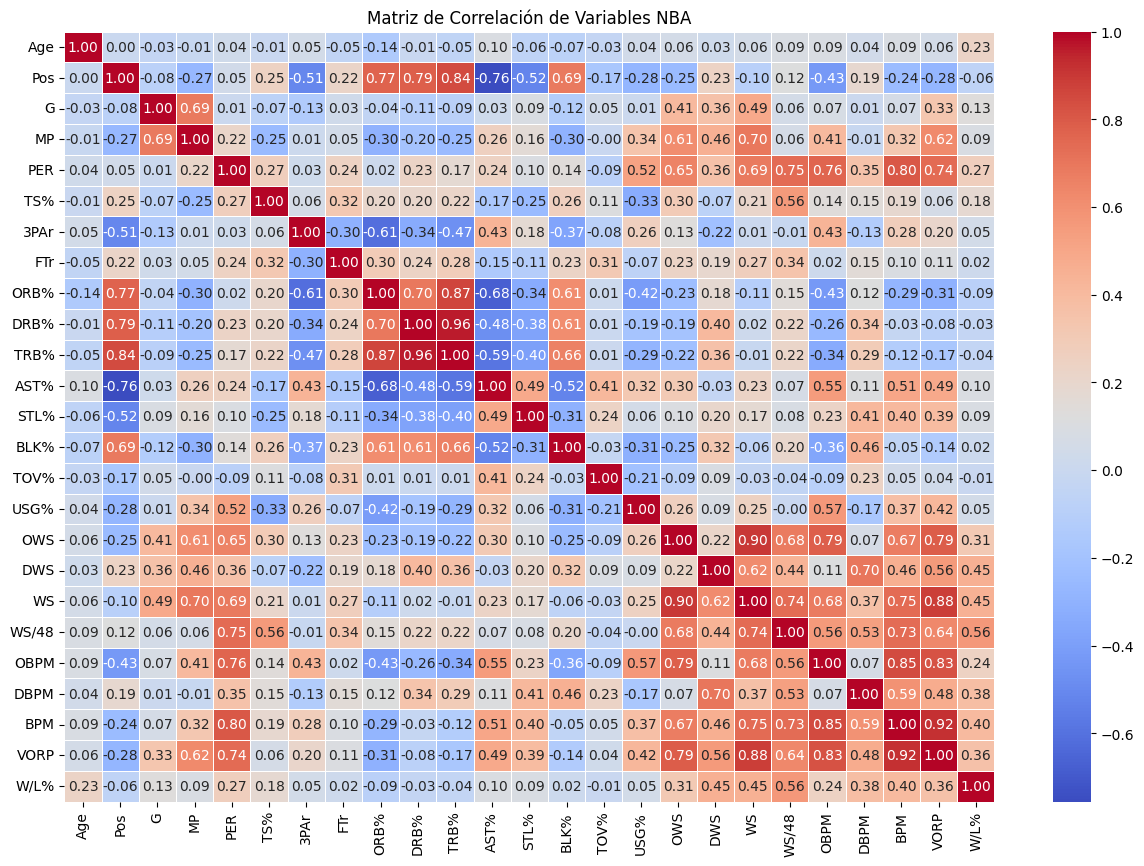

In [ ]:
# Seleccionar solo variables numéricas candidatas para el modelo
# Excluimos identificadores y la variable objetivo 'Share' para el análisis de colinealidad
features_num = df.select_dtypes(include=[np.number]).drop(columns=['Season', 'Share', 'MVP_Rank'], errors='ignore')

# Calcular la matriz de correlación
corr_matrix = features_num.corr()

# Visualización
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlación de Variables NBA")
plt.show()

In [ ]:
# Calculamos la correlación de todo el dataset original, pero solo nos quedamos con la columna de 'Share'
correlation_with_share = df.select_dtypes(include=[np.number]).drop(columns=['Season', 'MVP_Rank'], errors='ignore').corr()['Share'].sort_values(ascending=False)

print(correlation_with_share)

Share    1.000000
PER      0.641955
VORP     0.621523
BPM      0.602444
WS       0.578890
WS/48    0.537677
OBPM     0.534502
OWS      0.509515
DWS      0.381183
USG%     0.362379
W/L%     0.327652
DBPM     0.319242
MP       0.241174
AST%     0.221380
STL%     0.129648
FTr      0.128220
G        0.115054
TS%      0.110713
DRB%     0.105341
TRB%     0.064399
Age      0.046428
BLK%     0.023482
3PAr     0.021029
TOV%     0.004548
Pos     -0.031184
ORB%    -0.044161
Name: Share, dtype: float64




*   OWS, DWS, WS; ¿WS = OWS + DWS? y nos quedamos con WS/48, dato normalizado
*   OBPM, DBPM, VORP; BPM = OBPM + DBPM y correlación de 0.93 entre VORP y BPM, nos quedamos con BPM
*   ORB%, DRB%; TRB% = ORB + DRB, nos quedamos TRB



In [ ]:
df = df.drop(columns=['OWS', 'DWS', 'WS', 'OBPM', 'DBPM', 'BPM', 'ORB%', 'DRB%', 'VORP', 'WS/48'])

In [ ]:
columns_to_exclude = ['Share', 'Season', 'MVP_Rank', 'Awards', 'Player', 'Team']
X_eda = df.select_dtypes(include=[np.number]).drop(columns=[c for c in columns_to_exclude if c in df.columns], errors='ignore').fillna(0)
y_eda = df['Share']

# 2. Configuración de la iteración
n_iterations = 100
mi_results_list = []

print(f"Iniciando {n_iterations} iteraciones de Mutual Information (sin MVP_Rank) para evitar leakage...")

for i in range(n_iterations):
    scores = mutual_info_regression(X_eda, y_eda, random_state=i)
    mi_results_list.append(scores)

# 3. Cálculo de la media y creación del DataFrame de resultados
mi_avg = np.mean(mi_results_list, axis=0)
mi_final = pd.Series(mi_avg, index=X_eda.columns).sort_values(ascending=False)

print("\n--- Resultados de Información Mutua (Variables Estadísticas Puras) ---")
print(mi_final)


Iniciando 100 iteraciones de Mutual Information (sin MVP_Rank) para evitar leakage...

--- Resultados de Información Mutua (Variables Estadísticas Puras) ---
PER     0.244284
W/L%    0.125072
USG%    0.111724
MP      0.081857
AST%    0.050167
FTr     0.034839
TS%     0.034005
Age     0.019042
G       0.018416
TOV%    0.016624
BLK%    0.015384
TRB%    0.014679
STL%    0.011737
Pos     0.010437
3PAr    0.006638
dtype: float64


In [ ]:
df = df.drop(columns=['3PAr', 'Pos', 'TOV%', 'BLK%', 'G'])

In [ ]:
columns_to_exclude = ['Share', 'Season', 'MVP_Rank', 'Awards', 'Player', 'Team']
X = df.select_dtypes(include=[np.number]).drop(columns=[c for c in columns_to_exclude if c in df.columns], errors='ignore').fillna(0)
y = df['Share']

vif_results = compute_vif(X)
print(vif_results)

  Variable       VIF
0      PER  3.840751
1     USG%  3.226124
2     TRB%  2.855070
3      TS%  2.367123
4     AST%  2.170944
5     STL%  1.736406
6       MP  1.308215
7      FTr  1.240805
8     W/L%  1.197990
9      Age  1.092010


In [ ]:
df2 = X + y

In [ ]:
df2 = pd.concat([X.copy(), y], axis=1)

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2006 entries, 0 to 2081
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     2006 non-null   float64
 1   MP      2006 non-null   float64
 2   PER     2006 non-null   float64
 3   TS%     2006 non-null   float64
 4   FTr     2006 non-null   float64
 5   TRB%    2006 non-null   float64
 6   AST%    2006 non-null   float64
 7   STL%    2006 non-null   float64
 8   USG%    2006 non-null   float64
 9   W/L%    2006 non-null   float64
 10  Share   2006 non-null   float64
dtypes: float64(11)
memory usage: 252.6 KB


In [ ]:
# Calculamos la correlación de todo el dataset original, pero solo nos quedamos con la columna de 'Share'
correlation_with_share = df2.select_dtypes(include=[np.number]).corr()['Share'].sort_values(ascending=False)

print(correlation_with_share)

Share    1.000000
PER      0.641955
USG%     0.362379
W/L%     0.327652
MP       0.241174
AST%     0.221380
STL%     0.129648
FTr      0.128220
TS%      0.110713
TRB%     0.064399
Age      0.046428
Name: Share, dtype: float64


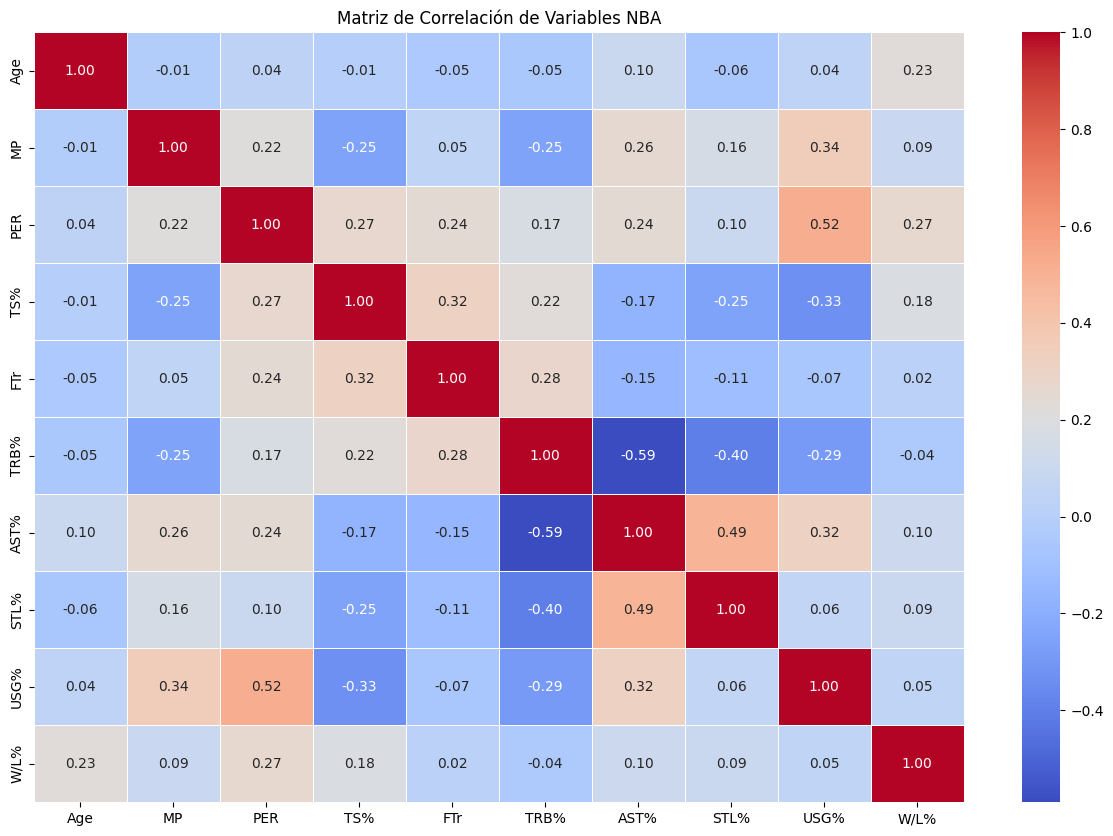

In [ ]:
# Seleccionar solo variables numéricas candidatas para el modelo
# Excluimos identificadores y la variable objetivo 'Share' para el análisis de colinealidad
features_num = df2.select_dtypes(include=[np.number]).drop(columns=['Season', 'Share', 'MVP_Rank'], errors='ignore')

# Calcular la matriz de correlación
corr_matrix = features_num.corr()

# Visualización
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlación de Variables NBA")
plt.show()

In [ ]:
df2 = pd.concat([df2, df[['Season', 'MVP_Rank', 'Awards', 'Player', 'Team']]], axis=1)

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2006 entries, 0 to 2081
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       2006 non-null   float64
 1   MP        2006 non-null   float64
 2   PER       2006 non-null   float64
 3   TS%       2006 non-null   float64
 4   FTr       2006 non-null   float64
 5   TRB%      2006 non-null   float64
 6   AST%      2006 non-null   float64
 7   STL%      2006 non-null   float64
 8   USG%      2006 non-null   float64
 9   W/L%      2006 non-null   float64
 10  Share     2006 non-null   float64
 11  Season    2006 non-null   int64  
 12  MVP_Rank  2006 non-null   int64  
 13  Awards    2006 non-null   object 
 14  Player    2006 non-null   object 
 15  Team      2006 non-null   object 
dtypes: float64(11), int64(2), object(3)
memory usage: 331.0+ KB


In [ ]:
df2.to_csv('datos_1980-2025_procesados.csv', index=False)

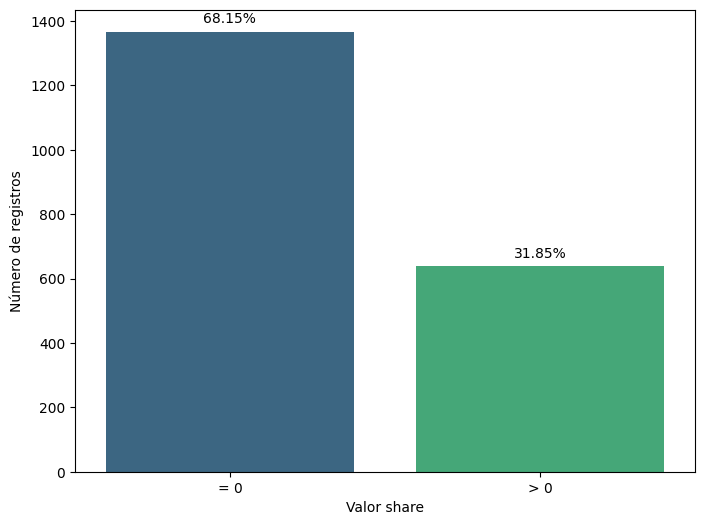

In [ ]:
# Visualización para saber que porcentaje de elementos tienen un share > 0
share_counts = df2['Share'].apply(lambda x: '> 0' if x > 0 else '= 0').value_counts()
share_percentages = share_counts / len(df2) * 100

plt.figure(figsize=(8, 6))
sns.barplot(x=share_percentages.index, y=share_counts.values, hue=share_percentages.index, palette='viridis', legend=False)

plt.ylabel('Número de registros')
plt.xlabel('Valor share')

for index, row in enumerate(share_percentages.values):
    plt.text(index, share_counts.values[index] + (max(share_counts.values) * 0.02), f'{row:.2f}%', color='black', ha="center")

plt.show()